In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import PALETTES, stream_width_aligned_permutations
from converters.img_converter import ImgConverter
from converters.line_heuristics.harmony_search import HarmonyLineSearch
from converters.tile.nearest import Tile2SymbNearest

from tests.experimental.test_loop import lazy_converter_loop

FONT_PATH = "../../../../fonts/OpenSans-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
SYMBOLS = list(stream_width_aligned_permutations(PALETTES['asciis'], FONT, skip_chance=0.3))
MAX_COLS = 10
MAX_LINES = 10
NUM_IMGS = 10
GENS = 9
GENS_STEP = 3
IMG_SET_PATH = "../../../../imgs/BSDS500-ds"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:NUM_IMGS]]


In [2]:
from PIL import Image
from image.processing import preprocess_img
from rendering.image import render_symbols_img
tile_converter = Tile2SymbNearest(symbols=SYMBOLS,
                                  font=FONT,
                                  val_wh=(7, 7))
line_converter = HarmonyLineSearch(symbols=SYMBOLS,
                                   font=FONT,
                                   generations=GENS,
                                   pop_count=3,
                                   tile_converter=tile_converter)

converter = ImgConverter(line_converter, FONT)

d:\CS Projects\python-playground\python-ascii-art\tests\experimental\grayscale\non_monospaced\../../../../src\converters\tile\nearest.py:40: UserWarning: It is recommended to use mode = grid-constant instead of constant when grid_mode is True.
  tile = zoom(tile, zoom_factors, order=0, grid_mode=True)


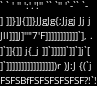

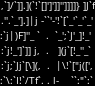

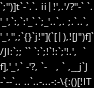

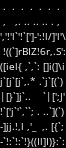

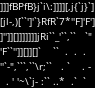

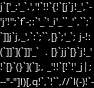

In [3]:
results = []
for img_path in IMG_PATHS[:6]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = converter.img2symbols(img,
                                    max_cols=MAX_COLS,
                                    max_lines=MAX_LINES,
                                    gens_per_step=1000)
    display(render_symbols_img(res_arr, FONT))


Min: 0.1164 | Max: 0.1964 | Mean: 0.1541 | Std: 0.0277
Min: 0.1264 | Max: 0.2110 | Mean: 0.1722 | Std: 0.0289
Min: 0.1441 | Max: 0.2256 | Mean: 0.1807 | Std: 0.0260


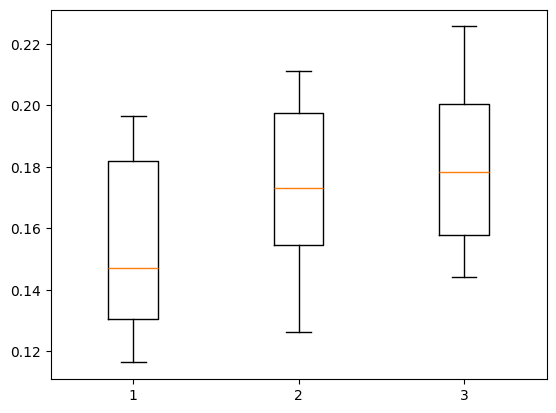

In [4]:
similarity_scores = lazy_converter_loop(IMG_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        

d:\CS Projects\python-playground\python-ascii-art\tests\experimental\grayscale\non_monospaced\../../../../src\converters\tile\nearest.py:40: UserWarning: It is recommended to use mode = grid-constant instead of constant when grid_mode is True.
  tile = zoom(tile, zoom_factors, order=0, grid_mode=True)


Min: 0.1039 | Max: 0.1740 | Mean: 0.1306 | Std: 0.0202
Min: 0.1170 | Max: 0.1756 | Mean: 0.1377 | Std: 0.0180
Min: 0.1190 | Max: 0.1756 | Mean: 0.1440 | Std: 0.0177


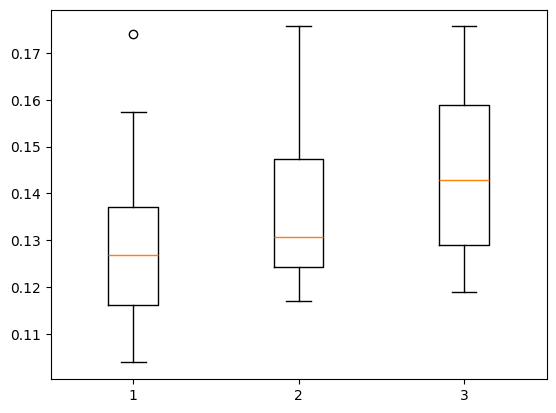

In [5]:
IMG_BIN_SET_PATH = "../../../../imgs/BSDS500-ds-bin"
IMG_BIN_PATHS = [os.path.join(IMG_BIN_SET_PATH, img_name)
                 for img_name in os.listdir(IMG_BIN_SET_PATH)[:NUM_IMGS]]

similarity_scores = lazy_converter_loop(IMG_BIN_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        

d:\CS Projects\python-playground\python-ascii-art\tests\experimental\grayscale\non_monospaced\../../../../src\converters\tile\nearest.py:40: UserWarning: It is recommended to use mode = grid-constant instead of constant when grid_mode is True.
  tile = zoom(tile, zoom_factors, order=0, grid_mode=True)


Min: 0.0491 | Max: 0.3204 | Mean: 0.1341 | Std: 0.0765
Min: 0.0609 | Max: 0.3558 | Mean: 0.1736 | Std: 0.0952
Min: 0.0702 | Max: 0.3876 | Mean: 0.1854 | Std: 0.0979


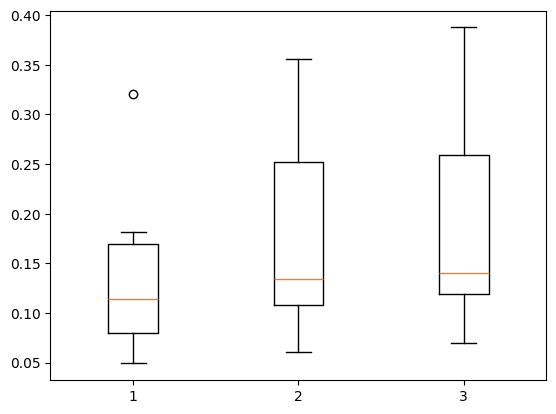

In [6]:
IMG_EDGE_SET_PATH = "../../../../imgs/BSDS500-ds-edge-bin"
IMG_EDGE_PATHS = [os.path.join(IMG_EDGE_SET_PATH, img_name)
                  for img_name in os.listdir(IMG_EDGE_SET_PATH)[:NUM_IMGS]]

similarity_scores = lazy_converter_loop(IMG_EDGE_PATHS,
                                        converter,
                                        FONT,
                                        max_cols=MAX_COLS,
                                        max_lines=MAX_LINES,
                                        gens=GENS,
                                        gens_per_step=GENS_STEP)

plt.boxplot(similarity_scores)
plt.show()
        